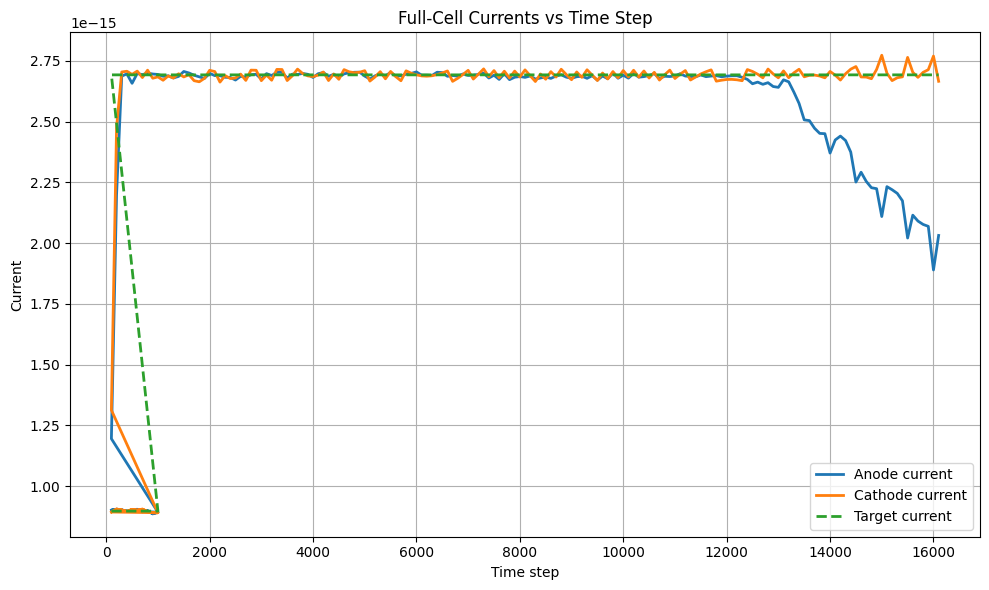

In [38]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"timestep:\s*(\d+).*?Anode current\s*=\s*([-eE0-9.]+),\s*Cathode current\s*=\s*([-eE0-9.]+),.*?Target Current\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        anode = abs(float(match.group(2)))  # absolute value
        cathode = float(match.group(3))
        target = float(match.group(4))
        data.append((timestep, anode, cathode, target))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["Timestep", "Anode", "Cathode", "Target"])

df = df[df["Timestep"] != 0] # Remove timestep 0


# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["Timestep"], df["Anode"], label="Anode current", linewidth=2)
plt.plot(df["Timestep"], df["Cathode"], label="Cathode current", linewidth=2)
plt.plot(df["Timestep"], df["Target"], '--', label="Target current", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Current")
plt.title("Full-Cell Currents vs Time Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


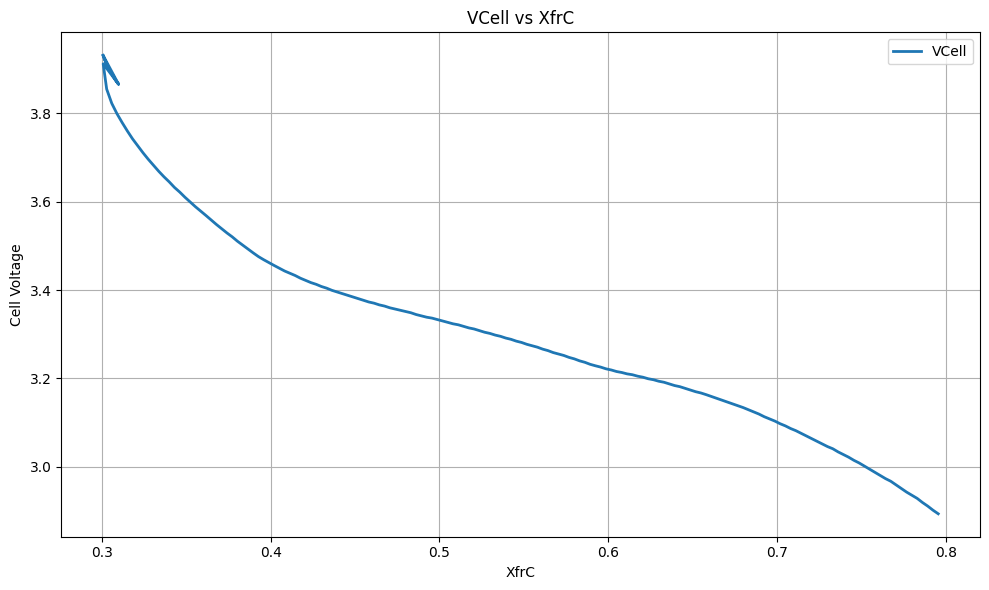

In [35]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        XfrC = float(match.group(1))
        vcell = abs(float(match.group(2)))  # absolute value
        data.append((XfrC, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["XfrC", "VCell"])

df = df[df["XfrC"] != 0.3] # Remove timestep 0


# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["XfrC"], df["VCell"], label="VCell", linewidth=2)

plt.xlabel("XfrC")
plt.ylabel("Cell Voltage")
plt.title("VCell vs XfrC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


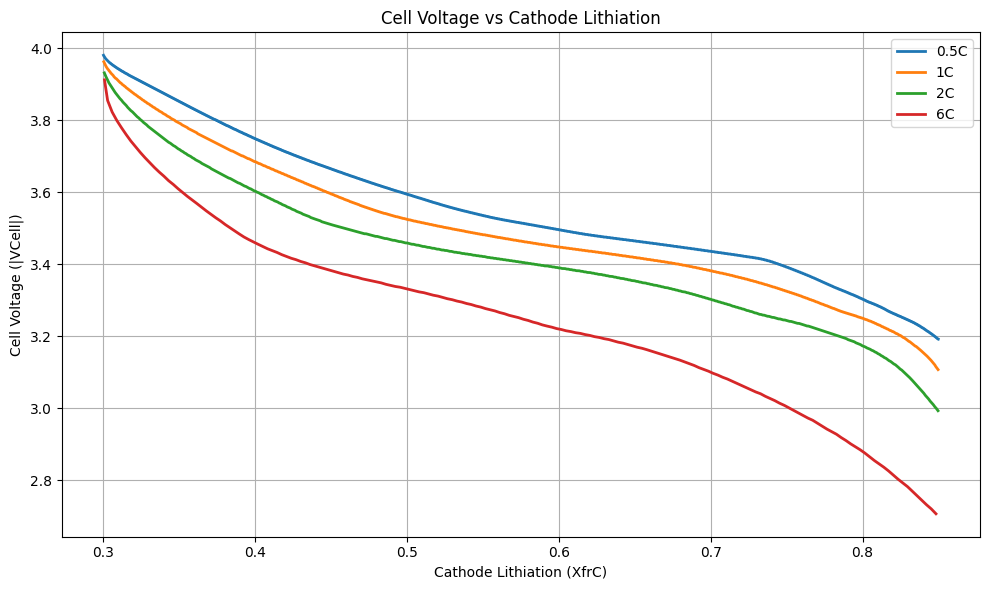

In [80]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def extract_data(file_path):
    """Extract (XfrC, VCell) pairs from a simulation output file."""
    pattern = re.compile(r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)")
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                XfrC = float(match.group(1))
                VCell = abs(float(match.group(2)))
                data.append((XfrC, VCell))
    df = pd.DataFrame(data, columns=["XfrC", "VCell"])
    df = df[df["XfrC"] != 0.3]  # remove initial timestep
    return df

# --- File paths ---
file1 = "../bin/3D_full_1C_0.85XfrC.txt"
file2 = "../bin/3D_full_0.5C_0.85XfrC.txt"
file3 = "../bin/3D_full_2C_0.85XfrC.txt"
file4 = "../bin/3D_full_6C_0.85XfrC.txt"

# --- Load both datasets ---
df1 = extract_data(file1)
df2 = extract_data(file2)
df3 = extract_data(file3)
df4 = extract_data(file4)

# --- Plot both ---
plt.figure(figsize=(10,6))
plt.plot(df2["XfrC"], df2["VCell"], label="0.5C", linewidth=2)
plt.plot(df1["XfrC"], df1["VCell"], label="1C", linewidth=2)
plt.plot(df3["XfrC"], df3["VCell"], label="2C", linewidth=2)
plt.plot(df4["XfrC"], df4["VCell"], label="6C", linewidth=2)


plt.xlabel("Cathode Lithiation (XfrC)")
plt.ylabel("Cell Voltage (|VCell|)")
plt.title("Cell Voltage vs Cathode Lithiation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
